In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/processed/cleaned_telco_churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.shape

(7032, 21)

In [4]:
df = df.drop("customerID", axis=1)

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df["Churn"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

df["Churn"].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

In [6]:
label_encoder = LabelEncoder()

for col in df.columns:
    
    if df[col].dtype == "object":
        
        df[col] = label_encoder.fit_transform(df[col])

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   str    
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   str    
 3   Dependents        7032 non-null   str    
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   str    
 6   MultipleLines     7032 non-null   str    
 7   InternetService   7032 non-null   str    
 8   OnlineSecurity    7032 non-null   str    
 9   OnlineBackup      7032 non-null   str    
 10  DeviceProtection  7032 non-null   str    
 11  TechSupport       7032 non-null   str    
 12  StreamingTV       7032 non-null   str    
 13  StreamingMovies   7032 non-null   str    
 14  Contract          7032 non-null   str    
 15  PaperlessBilling  7032 non-null   str    
 16  PaymentMethod     7032 non-null   str    
 17  Monthl

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   str    
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   str    
 3   Dependents        7032 non-null   str    
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   str    
 6   MultipleLines     7032 non-null   str    
 7   InternetService   7032 non-null   str    
 8   OnlineSecurity    7032 non-null   str    
 9   OnlineBackup      7032 non-null   str    
 10  DeviceProtection  7032 non-null   str    
 11  TechSupport       7032 non-null   str    
 12  StreamingTV       7032 non-null   str    
 13  StreamingMovies   7032 non-null   str    
 14  Contract          7032 non-null   str    
 15  PaperlessBilling  7032 non-null   str    
 16  PaymentMethod     7032 non-null   str    
 17  Monthl

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

NameError: name 'X' is not defined

In [11]:
X = df.drop("Churn", axis=1)

y = df["Churn"]

print(X.shape)
print(y.shape)

(7032, 19)
(7032,)


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(5625, 19)
(1407, 19)


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (5625, 19)
X_test: (1407, 19)
y_train: (5625,)
y_test: (1407,)


In [14]:
log_model = LogisticRegression(max_iter=2000)

log_model.fit(X_train, y_train)

print("Logistic Regression Trained Successfully")

ValueError: could not convert string to float: 'Female'

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   str    
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   str    
 3   Dependents        7032 non-null   str    
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   str    
 6   MultipleLines     7032 non-null   str    
 7   InternetService   7032 non-null   str    
 8   OnlineSecurity    7032 non-null   str    
 9   OnlineBackup      7032 non-null   str    
 10  DeviceProtection  7032 non-null   str    
 11  TechSupport       7032 non-null   str    
 12  StreamingTV       7032 non-null   str    
 13  StreamingMovies   7032 non-null   str    
 14  Contract          7032 non-null   str    
 15  PaperlessBilling  7032 non-null   str    
 16  PaymentMethod     7032 non-null   str    
 17  Monthl

In [16]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

for col in df.columns:
    
    if df[col].dtype == "object":
        
        df[col] = label_encoder.fit_transform(df[col])

print("Encoding Complete")

Encoding Complete


In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   str    
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   str    
 3   Dependents        7032 non-null   str    
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   str    
 6   MultipleLines     7032 non-null   str    
 7   InternetService   7032 non-null   str    
 8   OnlineSecurity    7032 non-null   str    
 9   OnlineBackup      7032 non-null   str    
 10  DeviceProtection  7032 non-null   str    
 11  TechSupport       7032 non-null   str    
 12  StreamingTV       7032 non-null   str    
 13  StreamingMovies   7032 non-null   str    
 14  Contract          7032 non-null   str    
 15  PaperlessBilling  7032 non-null   str    
 16  PaymentMethod     7032 non-null   str    
 17  Monthl

In [18]:
X = df.drop("Churn", axis=1)

y = df["Churn"]

print(X.shape)
print(y.shape)

(7032, 19)
(7032,)


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(5625, 19)
(1407, 19)


In [20]:
log_model = LogisticRegression(max_iter=2000)

log_model.fit(X_train, y_train)

print("Logistic Regression Trained Successfully")

ValueError: could not convert string to float: 'Female'

In [21]:
df.select_dtypes(include=['object']).columns.tolist()

C:\Users\acer\AppData\Local\Temp\ipykernel_3316\3633269985.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include=['object']).columns.tolist()


['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod']

In [22]:
object_cols = df.select_dtypes(include=['object']).columns

print("Object Columns:")
print(object_cols)

Object Columns:
Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='str')


C:\Users\acer\AppData\Local\Temp\ipykernel_3316\360348436.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_cols = df.select_dtypes(include=['object']).columns


In [23]:
from sklearn.preprocessing import LabelEncoder

for col in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

print("Encoding Complete")

Encoding Complete


C:\Users\acer\AppData\Local\Temp\ipykernel_3316\522480209.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include=['object']).columns:


In [24]:
df.select_dtypes(include=['object']).columns.tolist()

[]

In [25]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [27]:
log_model = LogisticRegression(max_iter=2000)
log_model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",2000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [28]:
print(df.select_dtypes(include=['object']).columns.tolist())

[]


In [29]:
X = df.drop("Churn", axis=1)

y = df["Churn"]

print(X.shape)
print(y.shape)

(7032, 19)
(7032,)


In [30]:
print(X.dtypes)

gender                int64
SeniorCitizen         int64
Partner               int64
Dependents            int64
tenure                int64
PhoneService          int64
MultipleLines         int64
InternetService       int64
OnlineSecurity        int64
OnlineBackup          int64
DeviceProtection      int64
TechSupport           int64
StreamingTV           int64
StreamingMovies       int64
Contract              int64
PaperlessBilling      int64
PaymentMethod         int64
MonthlyCharges      float64
TotalCharges        float64
dtype: object


In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(5625, 19)
(1407, 19)


In [32]:
X_train.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
6021,0,0,0,0,43,0,1,0,0,0,2,0,2,2,0,1,0,49.05,2076.20
3404,1,0,0,0,3,1,0,0,0,0,0,0,2,0,0,0,1,53.40,188.70
5474,0,0,1,0,55,1,2,1,0,0,2,0,0,0,0,1,2,77.75,4458.15
5515,1,0,1,1,45,1,0,0,2,0,0,2,0,0,2,0,0,54.65,2553.70
6328,0,0,1,1,55,1,2,1,2,0,0,0,2,2,1,0,3,100.90,5448.60


In [33]:
log_model = LogisticRegression(max_iter=2000)

log_model.fit(X_train, y_train)

print("Training Successful")

Training Successful


In [34]:
y_pred_log = log_model.predict(X_test)

print(y_pred_log[:10])

[0 0 1 0 0 0 0 1 0 0]


In [35]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred_log)

print("Accuracy:", accuracy)

Accuracy: 0.7853589196872779


In [36]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.49      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.77      0.79      0.78      1407



In [37]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_log)

print(cm)

[[920 113]
 [189 185]]


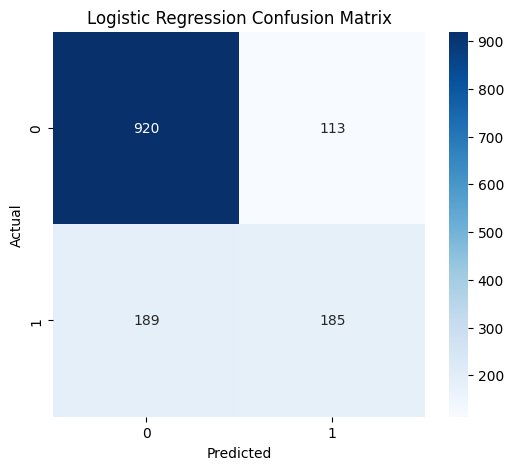

In [38]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [39]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

print("Random Forest Trained Successfully")

Random Forest Trained Successfully


In [40]:
y_pred_rf = rf_model.predict(X_test)

print(y_pred_rf[:10])

[0 0 1 0 0 1 0 1 0 0]


In [49]:
from sklearn.metrics import classification_report

print("Random Forest Classification Report")
print(classification_report(y_test, y_pred_rf))

Random Forest Classification Report
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.63      0.48      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.78      0.79      0.78      1407



In [41]:
rf_accuracy = accuracy_score(
    y_test,
    y_pred_rf
)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.7882018479033405


In [42]:
print(
    classification_report(
        y_test,
        y_pred_rf
    )
)

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.63      0.48      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.78      0.79      0.78      1407



In [43]:
cm_rf = confusion_matrix(
    y_test,
    y_pred_rf
)

print(cm_rf)

[[930 103]
 [195 179]]


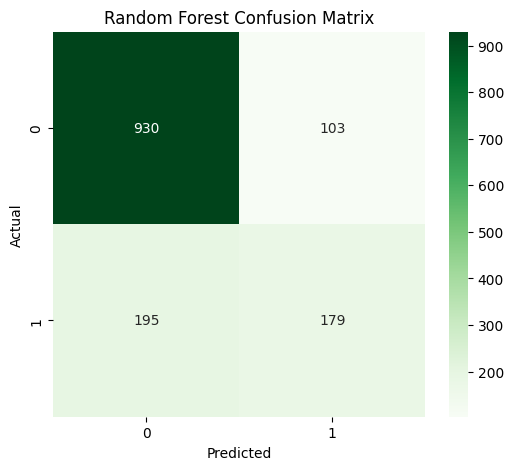

In [44]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Random Forest Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [45]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
18,TotalCharges,0.186602
17,MonthlyCharges,0.178367
4,tenure,0.155314
14,Contract,0.080190
16,PaymentMethod,0.051079
8,OnlineSecurity,0.048970
11,TechSupport,0.042888
7,InternetService,0.027614
0,gender,0.027456
9,OnlineBackup,0.026431


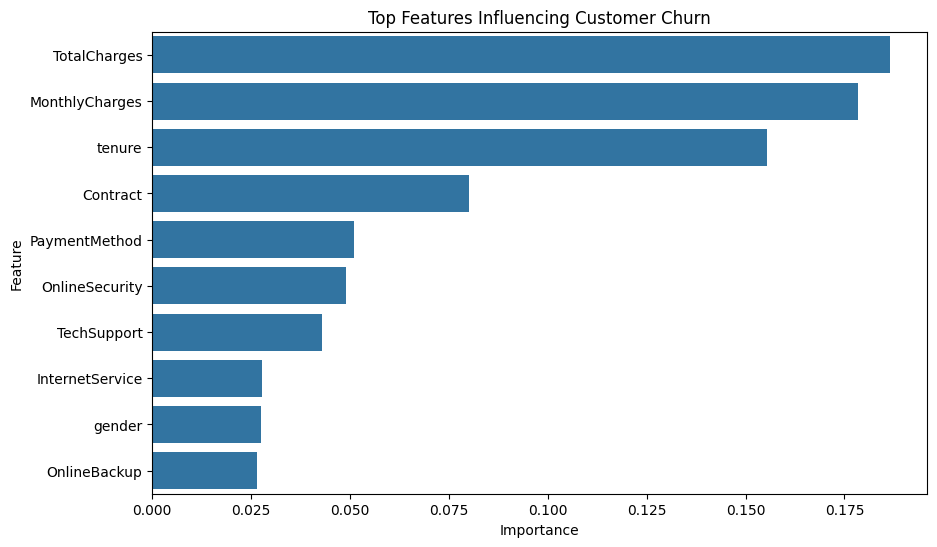

In [46]:
top10 = importance.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top10,
    x="Importance",
    y="Feature"
)

plt.title(
    "Top Features Influencing Customer Churn"
)

plt.show()

In [47]:
import joblib

joblib.dump(
    rf_model,
    "../models/churn_model.pkl"
)

['../models/churn_model.pkl']

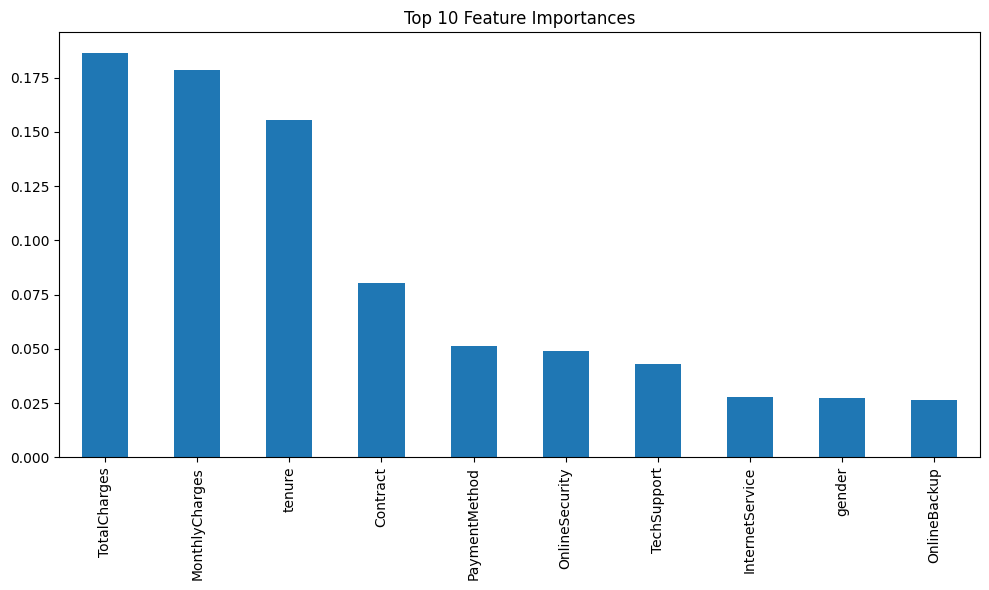

In [48]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
)

importance = importance.sort_values(
    ascending=False
).head(10)

plt.figure(figsize=(10,6))

importance.plot(kind='bar')

plt.title("Top 10 Feature Importances")

plt.tight_layout()

plt.savefig("../images/feature_importance.png")

plt.show()